# Set variables

In [1]:
GROUND_TRUTH_ROOT = "vctk/"
SENSOR_ROOT = "MICEMOUSE/gen/csv"
BATCH_SIZE = 16
seed = 42

## Import Needed Libraries

In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchvision.transforms

## Import our own backend

In [3]:
import core.nn.VCTK
from core.signal.preprocess import *
from core.nn.utils import normalize, denormalize, mapToBounds, apply_wiener
import whisper

## Set seed and logging level

In [4]:
import logging
# fix seed for reproducibility
np.random.seed(seed)
torch.manual_seed(seed)
logging.basicConfig(level=logging.INFO)

## Initialize the dataloaders

In [5]:
Fs = 16000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
groundTruthConfig = {
    "root": GROUND_TRUTH_ROOT,
    "download": False,
}
sensorConfig = {
    "root": SENSOR_ROOT,
    "Fs": Fs,
    "device": device,
    "resampleMethod": 'sinc'
}

paired_ds = core.nn.VCTK.PairedAudioDataset(groundTruthConfig, sensorConfig)
filtered_paired_ds = core.nn.VCTK.removeOutliers(paired_ds)
train_loader, test_loader, dev_loader = core.nn.VCTK.getAudioLoaders(filtered_paired_ds, device = device, batch_size=BATCH_SIZE)

INFO:root:Initializing PairedAudioDataset...


Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Train: 2258 batches = 36128 samples
Test: 332 batches = 5312 samples
Dev: 67 batches = 1072 samples


## Load in the Noise data and build the Wiener Filter

In [6]:
from math import ceil
_, Xnoise, Ynoise = processFromFile("MICEMOUSE/gen/noise/noise_2023-11-03_21-00-40.csv", method='sinc')
# Pad to closest 16000
Fs = 16000
noise = F.pad((Xnoise+Ynoise)/2, (0, ceil((Xnoise.shape[0] / (5 * Fs)))*(5 * Fs) - Xnoise.shape[0]), "constant", 0)
noise = noise.reshape(-1, 5 * Fs)

100%|██████████| 67/67 [00:09<00:00,  6.95it/s]


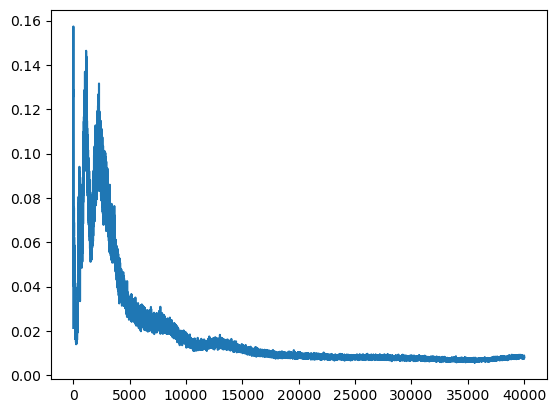

In [7]:
# compute FFT in dev set
Data_PSD = []
Noisy_PSD = []
for Xorig, Yorig in tqdm(dev_loader):
    # Get FFTs and aggregate
    Yorig = torch.fft.rfft(Yorig.squeeze().reshape(-1, 5 * Fs).to(device), dim = -1)
    Xorig = torch.fft.rfft(Xorig.squeeze().reshape(-1, 2, 5 * Fs).to(device), dim = -1)
    Data_PSD.append(Yorig)
    Noisy_PSD.append(Xorig)
# Compute average PSD
avgData_PSD = torch.cat(Data_PSD, dim=0).abs().mean(dim=0).cpu()
avgNoisy_PSD = torch.cat(Noisy_PSD, dim=0).abs().mean(dim=0).cpu().mean(dim=0)
# Compute FFT
noiseFFT = torch.fft.rfft(noise, dim=1)
noiseFFT = torch.abs(noiseFFT)
noiseFFT = noiseFFT.mean(dim=0)
H = avgData_PSD / (avgData_PSD + noiseFFT)
plt.plot(H.abs())

## Prepare the transforms to and from the spectrogram domain

In [8]:
import einops
tforms = core.nn.utils.buildTransforms(device = device, 
                                        Fs = Fs, 
                                        n_fft = 800, 
                                        win_length = 800,
                                        hop_length = 160,
                                        n_mels = 80,
                                        f_max_mouse = 8000,
                                        f_max_full = 8000,
                                        )
specFn, inverseSpecFn, melFilterMouse, melFilter, inverseMelFn = tforms

toMelDB = lambda batch: core.nn.utils.toMelDB(batch, specFn=specFn, mousemelfilters=melFilterMouse, fullmelfilter=melFilter)

def computeUnboundedSpec(X):
    ms = True if X.shape[1] == 2 else False
    if ms:
        X -= einops.reduce(X, "b c t -> b c ()", "mean")  # Remove mean
    else:
        X -= einops.reduce(X, "b t -> b ()", "mean")  # Remove mean
    X /= torch.std(X)                          # Normalize                                        
    X = specFn(X)                                 # Convert to mel
    X = X.abs().pow(2)                           # Power
    
    if ms:
        X = torch.einsum("bkct,fc->bkft", X, melFilterMouse)
        X = einops.rearrange(X, "b c m t -> b (m c) t", c=2)
    else:
        X = torch.einsum("bct,fc->bft", X, melFilter) # Apply mel filter
        
    X = (torch.maximum(torch.clamp(X, min=1e-10).log10(), torch.clamp(X, min=1e-10).log10().max() - 8.0) + 4.0)/ 4.0    # Convert to dB
    return X

# # The following code is used to compute the min and max values of the spectrograms

mnmn = torch.inf
mxmx = -torch.inf
for Mwav, Wwav in dev_loader:
    MwavFilt = apply_wiener(Mwav, H.to(device))
    Mfilt = computeUnboundedSpec(MwavFilt)
    M = computeUnboundedSpec(Mwav)
    W = computeUnboundedSpec(Wwav)
    mnmn = min(mnmn, M.min(), W.min(), Mfilt.min())
    mxmx = max(mxmx, M.max(), W.max(), Mfilt.max())

import einops


def computeSpec(X):
    X = computeUnboundedSpec(X)
    X = (X - mnmn) / (mxmx - mnmn)               # Map to bounds
    X = torch.clamp(X, 0, 1)                    # Clamp to [0, 1]
    X = 2 * X - 1                               # Map to [-1, 1]
    return X

def fromSpec(X):
    if X.shape[1] == 160:
        X = einops.rearrange(X, "b (m c) t -> b c m t", c=2)
        X = torch.mean(X, dim=1)
    X = (X + 1) / 2
    X = X * (mxmx - mnmn) + mnmn
    X = 10 ** (4 * X - 4)
    X = inverseMelFn(X)
    X = inverseSpecFn(X)
    return X

### Plot the spectrum of the sensor data, ground truth, and post-Wiener Filter sensor data

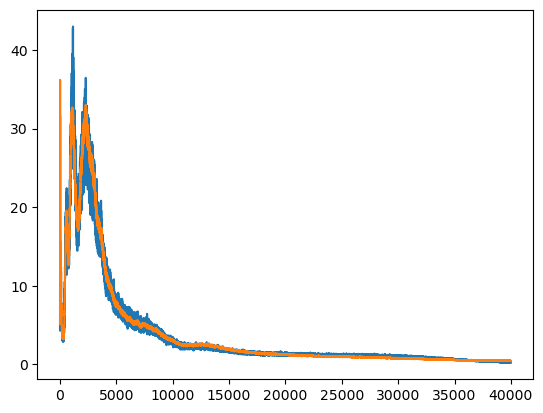

In [9]:
postFiltering = H.abs() * avgNoisy_PSD.abs()
# fft bin to frequency
X = torch.fft.rfftfreq(80000, 1/16000)

# build a dataframe with 4 columns: frequency, avgNoisy, avgData_PSD, postFiltering
df = pd.DataFrame()
df['frequency'] = X
df['avgNoisy'] = avgNoisy_PSD
df['avgData'] = avgData_PSD
df['postFiltering'] = postFiltering
# save the dataframe
df.to_csv('dataDist.csv', index=False)
plt.plot(postFiltering)
plt.plot(avgData_PSD)

### Load in the Whisper model (encoder only)

In [10]:
perceptualEmbedding = whisper.load_model("tiny").encoder.to(device)
perceptualEmbedding.eval()
for p in perceptualEmbedding.parameters():
    p.requires_grad = False

### Define the filtering NN

In [11]:
from core.nn.whisperPrimitives import *
embed_d = 384
n_head = 6
n_layer = 4
k_size = 15
padding = k_size // 2
n_mels = 80
model = nn.Sequential(
    nn.Conv1d(n_mels * 2, embed_d, k_size, padding=padding),
    nn.GELU(),
    TransformerChain(n_ctx=501, n_state=embed_d, n_head = n_head, n_layer=n_layer),
    nn.GELU(),
    nn.Conv1d(embed_d, n_mels * 4, k_size, padding=padding),
    nn.GELU(),
    nn.Conv1d(n_mels * 4, n_mels, 1, padding=0),
).to(device)

## Define Loss Functions, Optimizer, and Scheduler

In [12]:
def frobenius_norm(X):
    return torch.sqrt(torch.sum(X ** 2))

def spectral_convergence(X, Y):
    return frobenius_norm(X - Y) / frobenius_norm(Y)

lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.707)

l1_loss = nn.L1Loss()
l2_loss = nn.MSELoss()
huber_loss = nn.HuberLoss()
perceptual_loss = lambda x, y: l2_loss(perceptualEmbedding(x), perceptualEmbedding(y))
pad_fn = lambda x, y: (F.pad(x, (0, 3000 - x.shape[-1])), F.pad(y, (0, 3000 - y.shape[-1])))

# Uncomment the losses you want to use, Huber loss is the most stable, perceptual loss is the most effective but takes the longest to train, we use a weighted sum of the losses for now
loss_fn = lambda x, y: (
    # l2_loss(x, y) +
    # l1_loss(x, y) +
    perceptual_loss(*pad_fn(x, y)) + 
    huber_loss(x, y)
)

### Training Helpers

In [13]:
def update_model(model, batch):
    model.train()
    optimizer.zero_grad()
    X = batch[0].to(device)
    Y = batch[1].to(device)
    
    # Apply wiener filter, normalize, convert to mel, map to bounds
    X = apply_wiener(X, H.to(device))
    X = computeSpec(X)
    Y = computeSpec(Y)
    
    # Train
    recon_batch = model(X)
    loss = loss_fn(recon_batch, Y)
    loss.backward()
    optimizer.step()
    return loss.item()

def train(model, loader, epochs = 10):
    model.train()
    with tqdm(total = epochs * len(loader)) as pbar:
        for epoch in range(epochs):
            for batch_idx, batch in enumerate(loader):
                loss = update_model(model, batch)
                pbar.set_description(f"Epoch {epoch}/{epochs}\tBatch {batch_idx}/{len(loader)}\tLoss {loss}")
                pbar.update(1)
                # wandb.log({"loss": loss}, step = epoch * len(loader) + batch_idx)
            # save model
            scheduler.step()
            torch.save(model.state_dict(), f"model_SUM_E{epoch}_L{loss:.2f}.pt")

### Train

In [14]:
# train(model, train_loader, epochs = 30)
model.load_state_dict(torch.load("models/VCTK_filter_model.model", map_location=device))

<All keys matched successfully>

In [15]:
torch.save(model.state_dict(), "models/VCTK_filter_model.model")

### Show one sample

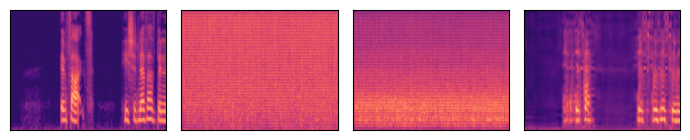

In [16]:
# run one test batch
model.eval()

with torch.no_grad():
    Xraw, Y = next(iter(dev_loader))
    Xfilt = apply_wiener(Xraw, H.to(device))
    Xraw = computeSpec(Xraw)
    Xfilt = computeSpec(Xfilt)
    Y = computeSpec(Y)

    recon_batch = model(Xfilt)

fig, ax = plt.subplots(1, 4, figsize=(7, 1.5))
i = 0
ax[0].imshow(Y[i, :, :301].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1, cmap="magma")
ax[0].set_xticks([]); ax[0].set_yticks([])
ax[1].imshow(Xraw[i, :, :301].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1, cmap="magma")
ax[1].set_xticks([]); ax[1].set_yticks([])
ax[2].imshow(Xfilt[i, :, :301].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1, cmap="magma")
ax[2].set_xticks([]); ax[2].set_yticks([])
ax[3].imshow(recon_batch[i, :, :301].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1, cmap="magma")
ax[3].set_xticks([]); ax[3].set_yticks([])
fig.tight_layout()
plt.show()

### Compute the metrics needed

In [17]:
import torchmetrics
import einops

inverseSpecFn = torchaudio.transforms.GriffinLim(
    n_fft=800,
    win_length=800,
    hop_length=160,
    power=2,
).to(device)

computeSNR = torchmetrics.audio.ScaleInvariantSignalNoiseRatio().to(device)
computeSTOI= torchmetrics.audio.ShortTimeObjectiveIntelligibility(Fs).to(device)
computePESQ = torchmetrics.audio.PerceptualEvaluationSpeechQuality(Fs, "wb").to(device)

In [19]:
def process_audio(Mwav, Wwav, model, device):
    MwavFilt = apply_wiener(Mwav, H.to(device))
    Mspec = computeSpec(MwavFilt)
    Mnofiltspec = computeSpec(Mwav)
    Wspec = computeSpec(Wwav)

    # Perform model prediction
    recon_batch = model(Mspec.to(device))

    recon_batch = fromSpec(recon_batch)

    # Process the original, no-filter and whitenoise spectrums
    Mnofiltspec = fromSpec(Mnofiltspec)
    Mwav = fromSpec(Mspec)
    Wwav = fromSpec(Wspec)

    return Mnofiltspec, Mwav, Wwav, recon_batch

def compute_metrics(model_output, Mnofiltspec, Mwav, Wwav, computeSNR, computeSTOI, computePESQ):
    metrics = {
        "SNR": {"model": computeSNR(model_output, Wwav),
                "baseline": computeSNR(Mnofiltspec, Wwav),
                "wiener": computeSNR(Mwav, Wwav)},
        "STOI": {"model": computeSTOI(model_output, Wwav),
                 "baseline": computeSTOI(Mnofiltspec, Wwav),
                 "wiener": computeSTOI(Mwav, Wwav)},
        "PESQ": {"model": computePESQ(model_output, Wwav),
                 "baseline": computePESQ(Mnofiltspec, Wwav),
                 "wiener": computePESQ(Mwav, Wwav)}
    }
    return metrics

metrics = {}
c = 1
# Main processing loop
with torch.no_grad():
    with tqdm(total=len(test_loader)) as pbar:
        for i, (Xorig, Yorig) in enumerate(test_loader):
            Mwav, Wwav = next(iter(dev_loader))
            Mnofiltspec, Mwav, Wwav, recon_batch = process_audio(Mwav, Wwav, model, device)
            computedMetrics = compute_metrics(recon_batch, Mnofiltspec, Mwav, Wwav, computeSNR, computeSTOI, computePESQ)

            # Save metrics
            for metric in computedMetrics:
                for method in computedMetrics[metric]:
                    if metric not in metrics:
                        metrics[metric] = {}
                    if method not in metrics[metric]:
                        metrics[metric][method] = []
                    metrics[metric][method].append(computedMetrics[metric][method].item())

            c += Xorig.shape[0]
            pbar.update(1)


100%|██████████| 332/332 [30:51<00:00,  5.58s/it]


In [20]:
# Compute average metrics
avgMetrics = {}
for metric in metrics:
    avgMetrics[metric] = {}
    for method in metrics[metric]:
        avgMetrics[metric][method] = np.mean(metrics[metric][method])

In [21]:
# print average metrics
for metric in avgMetrics:
    print(metric)
    for method in avgMetrics[metric]:
        print(f"\t{method}: {avgMetrics[metric][method]}")

SNR
	model: -28.185887308005828
	baseline: -47.75632551491979
	wiener: -40.953010651002444
STOI
	model: 0.5494554155921362
	baseline: 0.346104142716132
	wiener: 0.34448533137160614
PESQ
	model: 1.3581345404487057
	baseline: 1.15948422091553
	wiener: 1.1874271595334431


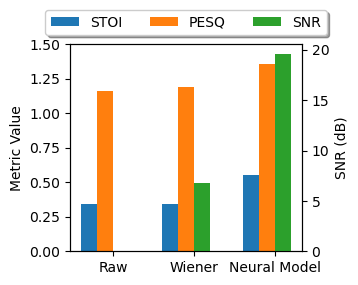

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data to resemble the uploaded histogram
models = ['STOI', 'PESQ', 'SNR']
stages = ['Raw', 'Wiener', 'Neural Model']
metricBars = np.array([
    [avgMetrics['STOI']['baseline'], avgMetrics['STOI']['wiener'], avgMetrics['STOI']['model']],
    [avgMetrics['PESQ']['baseline'], avgMetrics['PESQ']['wiener'], avgMetrics['PESQ']['model']],
    [avgMetrics['SNR']['baseline'] - avgMetrics['SNR']['baseline'], avgMetrics['SNR']['wiener'] - avgMetrics['SNR']['baseline'], avgMetrics['SNR']['model'] - avgMetrics['SNR']['baseline']],
])

# Show as a percentage over the baseline
# metricBars = metricBars / metricBars[:, 2][:, None] * 100

x = np.arange(len(stages))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(3.6, 3))
rects1 = ax.bar(x - 3*width/2, metricBars[0], width, label=models[0])
rects2 = ax.bar(x - width/2, metricBars[1], width, label=models[1])
rects3 = ax.bar(x + width/2, [0, 0, 0], width, label=models[2], color='C2')
# The third bar has a different scale, use a secondary axis
ax2 = ax.twinx()
rects3 = ax2.bar(x + width/2, metricBars[2], width, label=models[2], color='C2')
# User CMU Roman font, register it with matplotlib
ax2.set_ylabel('SNR (dB)')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Metric Value')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylim([0, 1.5])
ax.legend( loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, fancybox=True, shadow=True)

fig.tight_layout()
plt.savefig('fig/histogram.pdf', dpi=600)
plt.show()

In [23]:
print(metricBars) 

[[ 0.34610414  0.34448533  0.54945542]
 [ 1.15948422  1.18742716  1.35813454]
 [ 0.          6.80331486 19.57043821]]
